In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/test.csv
/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv


# Importing Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import RMSprop

Using TensorFlow backend.


# Load Data

In [3]:
train = pd.read_csv("../input/digit-recognizer/train.csv")
test = pd.read_csv("../input/digit-recognizer/test.csv")

In [4]:
train.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [5]:
print(train.shape)
train.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print(test.shape)
test.head()

(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Keeping dependent variable in y_train and independent variable in x_train

In [7]:
y_train = train["label"].astype('float32')
x_train = train.drop(labels = ["label"],axis = 1).astype('float32')

y_train.value_counts()

1.0    4684
7.0    4401
3.0    4351
9.0    4188
2.0    4177
6.0    4137
0.0    4132
4.0    4072
8.0    4063
5.0    3795
Name: label, dtype: int64

In [8]:
x_train.shape, y_train.shape

((42000, 784), (42000,))

# Missing Value

In [9]:
x_train.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [10]:
test.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object


There is no missing values in the train and test dataset. So we can safely go ahead.

# Normalization

We can divide each pixel with 255.0 to get NORMALIZATION

In [11]:
x_train = x_train / 255.0
test = test / 255.0

# Reshaping

Input data are in 1-D, we re- shape into 3-D matrix. 
For RGB images, there is 3 channels, we would have reshaped 784px vectors to 28x28x3 3D matrices.
For Black and White image we re-shape into 28x28x1

In [12]:
#Reshaping the data for 2D CNN input into (-1,28,28,1) size
x_train = np.array(x_train).reshape(-1,28,28,1)
test = np.array(test).reshape(-1,28,28,1)
print(x_train.shape)
print(test.shape)

(42000, 28, 28, 1)
(28000, 28, 28, 1)


5.0


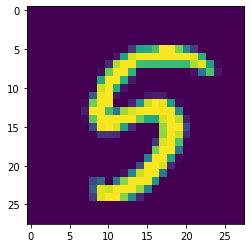

In [13]:
# Some examples
g = plt.imshow(x_train[8][:,:,0])
print(y_train[8])

# Label Encoding

In [14]:
# Encode labels to one hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])
y_train = keras.utils.to_categorical(y_train, 10)

# CNN Model

Forming Model

In [15]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (28,28,1)))
model.add(BatchNormalization())
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(512, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

Compile Model

In [16]:
optimizer = RMSprop(lr=0.001, rho=0.9, epsilon=1e-08, decay=0.0)

In [17]:
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

Getting the summary of Model

In [18]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 32)        832       
_________________________________________________________________
batch_normalization_1 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 28, 28, 32)        25632     
_________________________________________________________________
batch_normalization_2 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 64)       

Data Augmentation

In [19]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

Fit the Model

In [20]:
model.fit_generator(datagen.flow(x_train,y_train, batch_size = 86),epochs = 30, steps_per_epoch = x_train.shape[0]//64)
                            

Epoch 1/30
656/656 [==============================] - 29s 44ms/step - loss: 0.4671 - accuracy: 0.8977
Epoch 2/30
656/656 [==============================] - 22s 34ms/step - loss: 0.1558 - accuracy: 0.9638
Epoch 3/30
656/656 [==============================] - 22s 34ms/step - loss: 0.1308 - accuracy: 0.9714
Epoch 4/30
656/656 [==============================] - 23s 35ms/step - loss: 0.1109 - accuracy: 0.9758
Epoch 5/30
656/656 [==============================] - 22s 34ms/step - loss: 0.1060 - accuracy: 0.9768
Epoch 6/30
656/656 [==============================] - 23s 35ms/step - loss: 0.0965 - accuracy: 0.9792
Epoch 7/30
656/656 [==============================] - 23s 35ms/step - loss: 0.0893 - accuracy: 0.9809
Epoch 8/30
656/656 [==============================] - 22s 34ms/step - loss: 0.0850 - accuracy: 0.9817
Epoch 9/30
656/656 [==============================] - 24s 36ms/step - loss: 0.0746 - accuracy: 0.9828
Epoch 10/30
656/656 [==============================] - 23s 35ms/step - loss: 0.067

Prediction based on test data.

In [21]:
pred = model.predict(test)

# Convert predictions classes to one hot vectors 
final_pred = np.argmax(pred,axis = 1) 

In [22]:
final_pred

array([2, 0, 9, ..., 3, 9, 2])

In [23]:
sample_sub = pd.read_csv('../input/digit-recognizer/sample_submission.csv')

In [24]:
sample_sub = pd.DataFrame({"ImageId": list(range(1,len(final_pred)+1)),
                         "Label": final_pred})
sample_sub.to_csv('CNN_submission1.csv', index=False)
sample_sub.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
